## Regression

## Importing Essential Packages

In [47]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

## Linear Regression

### Linear Regression From Scratch

In [89]:
def linear_equation(weight_arr, b_init, feature_array):
    predicted_arr = []
    m = feature_array.shape[0]
    c = feature_array.shape[1]

    for i in range(m):
        row_equation = 0
        for j in range(c):
            row_equation += weight_arr[j] * feature_array[i, j]

        predicted_arr.append(row_equation + b_init)

    predicted_arr = np.array(predicted_arr)
    return predicted_arr 

In [91]:
def cost_function(number_of_rows, predicted_arr, target_array):
    summation = 0
    for i in range(predicted_arr.shape[0]):
        summation += (predicted_arr[i] - target_array[i]) ** 2
    mean_squared_error = summation / (2 * number_of_rows)
    return mean_squared_error

In [273]:
def gradient_descent(feature_array, weight_arr, old_bias, predicted_arr, target_array, m):
    learning_rate = 0.01
    updated_weights = []

    c = feature_array.shape[1]

    for i in range(c):
        summation_error_x = 0
        for j in range(m):
            summation_error_x += (predicted_arr[j] - target_array[j]) * feature_array[j][i]
        summation_error_x = learning_rate * (summation_error_x / m)
        new_weight = weight_arr[i] - summation_error_x
        updated_weights.append(new_weight)
    
    summation_error_x_b = 0
    for j in range(m):
        summation_error_x_b += (predicted_arr[j] - target_array[j])
    new_bias = old_bias - (learning_rate) * (summation_error_x_b / m)
    return updated_weights, new_bias
        

In [274]:
feature_array = np.array([
    [1, 1],
    [2, 1],
    [3, 2],
    [4, 3]
])

target_array = np.array([
    6,  
    8,  
    19,  
    29 
])

weight_arr = np.array([0, 0])

b_init = 0

In [275]:
feature_array, target_array, weight_arr, b_init


(array([[1, 1],
        [2, 1],
        [3, 2],
        [4, 3]]),
 array([ 6,  8, 19, 29]),
 array([0, 0]),
 0)

In [276]:
m = feature_array.shape[0]

predicted_arr = linear_equation(weight_arr, b_init, feature_array)
mse = cost_function(m, predicted_arr, target_array)

In [295]:
for i in range(1000):
    weight_arr, b_init = gradient_descent(feature_array, 
                        weight_arr,
                        b_init, 
                        predicted_arr,
                        target_array, m)
    predicted_arr = linear_equation(weight_arr, b_init, feature_array)
    mse = cost_function(m, predicted_arr, target_array)

In [296]:
weight_arr, b_init, mse

([np.float64(3.7217532209279556), np.float64(5.677164458802681)],
 np.float64(-3.5654645154824998),
 np.float64(0.35838304182424874))

In [297]:
target_array, predicted_arr

(array([ 6,  8, 19, 29]),
 array([ 5.83345316,  9.55520639, 18.95412406, 28.35304174]))

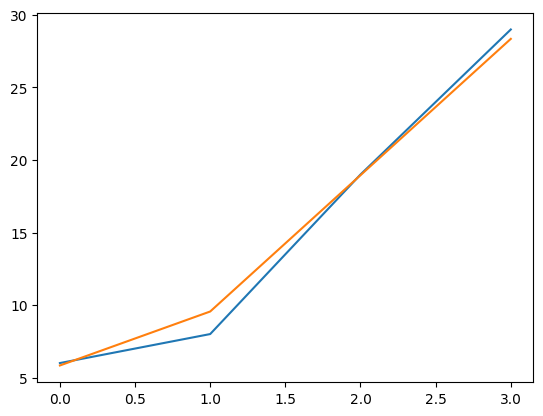

In [298]:
plt.plot(target_array)
plt.plot(predicted_arr)

**Using Numpy Linear Algerba Funtions Instead of Manual Functions**

In [ ]:
feature_array = np.array([
    [1, 1],
    [2, 1],
    [3, 2],
    [4, 3]
])

target_array = np.array([
    6,  
    8,  
    19,  
    29 
])

weight_arr = np.array([0, 0])

b_init = 0

In [322]:
def predict(X, w, b):
    return np.dot(X, w) + b

In [323]:
def cost_function(X, y, w, b):
    m = len(y)
    predictions = predict(X, w, b)
    cost = (1/ (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

In [324]:
def gradient_descent(X, y, w, b, alpha, iterations):
    m = len(y)
    
    for i in range(iterations):
        predictions = predict(X, w, b)
        errors = predictions - y
        
        dw = (1 / m) * np.dot(X.T, errors)
        db = (1 / m) * np.sum(errors)
        
        w = w - alpha * dw
        b = b - alpha * db
        
        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost_function(X, y, w, b)}")
    
    return w, b

In [325]:
feature_array = np.array([
    [1, 1],
    [2, 1],
    [3, 2],
    [4, 3]
])

target_array = np.array([6, 8, 19, 29])

weight_arr = np.array([0.0, 0.0])
b_init = 0.0

w_final, b_final = gradient_descent(
    feature_array,
    target_array,
    weight_arr,
    b_init,
    alpha=0.01,
    iterations=1000
)

print("Final weights:", w_final)
print("Final bias:", b_final)

Iteration 0, Cost: 126.80843984375
Iteration 100, Cost: 3.0380701074071306
Iteration 200, Cost: 2.321417054764411
Iteration 300, Cost: 1.7892200573174897
Iteration 400, Cost: 1.3924770043311945
Iteration 500, Cost: 1.0953544617303463
Iteration 600, Cost: 0.8716343020416686
Iteration 700, Cost: 0.7021205281569922
Iteration 800, Cost: 0.5727466970770668
Iteration 900, Cost: 0.4731945451007842
Final weights: [3.75434333 5.57820385]
Final bias: -3.455656222805472


### Linear Regression Using SciKit Learn